In [ ]:
# Simulations Monte-Carlo
import numpy as np
import matplotlib.pyplot as plt
import math


In [ ]:
class exponentiel_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x):
        return self.λ * np.exp(-self.λ * x)

    def E(self):
        return 1 / self.λ
    
    def V(self):
        return 1 / self.λ**2

In [ ]:
class poisson_distribution:

    def __init__(self, λ):
        self.λ = λ

    def f(self, x, T):
        return (np.exp(-self.λ*T)*(self.λ*T)**x) / math.factorial(x)
    
    def E(self, T):
        return self.λ*T
    
    def V(self, T):
        return self.λ*T

In [ ]:
class normal_distribution:

    def __init__(self, o, u):
        self.o = o
        self.u = u

    def f(self, x):
        a = -(x-self.u)**2 / (2*self.o**2)
        return (1 / (self.o*np.sqrt(2*np.pi))) * np.exp(a)

Nombre de joueurs présents pour 300 minutes : 3418


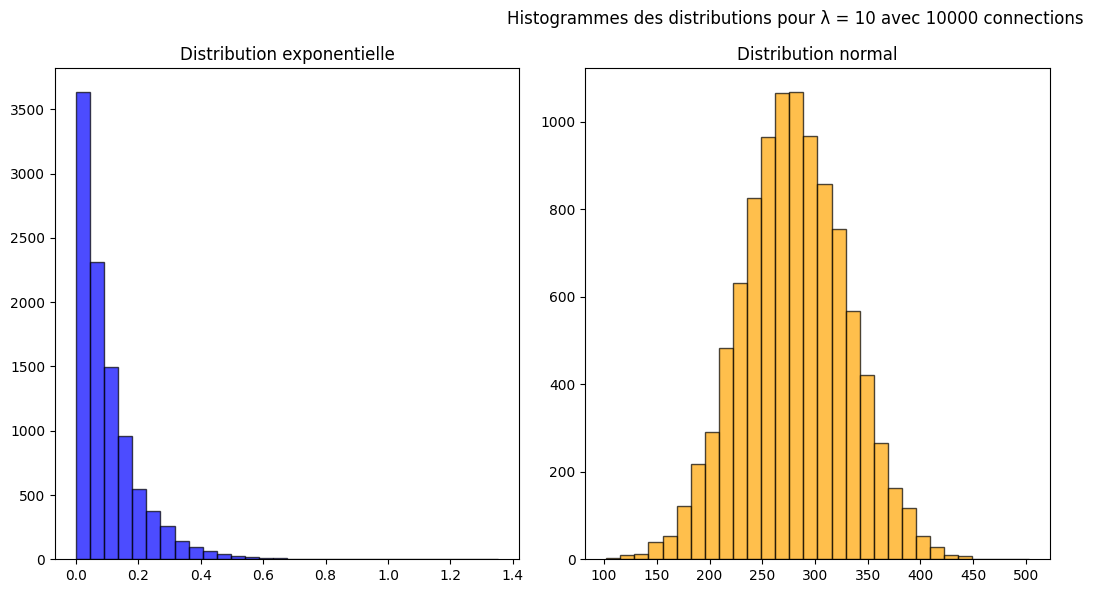

Nombre de joueurs présents pour 300 minutes : 3510


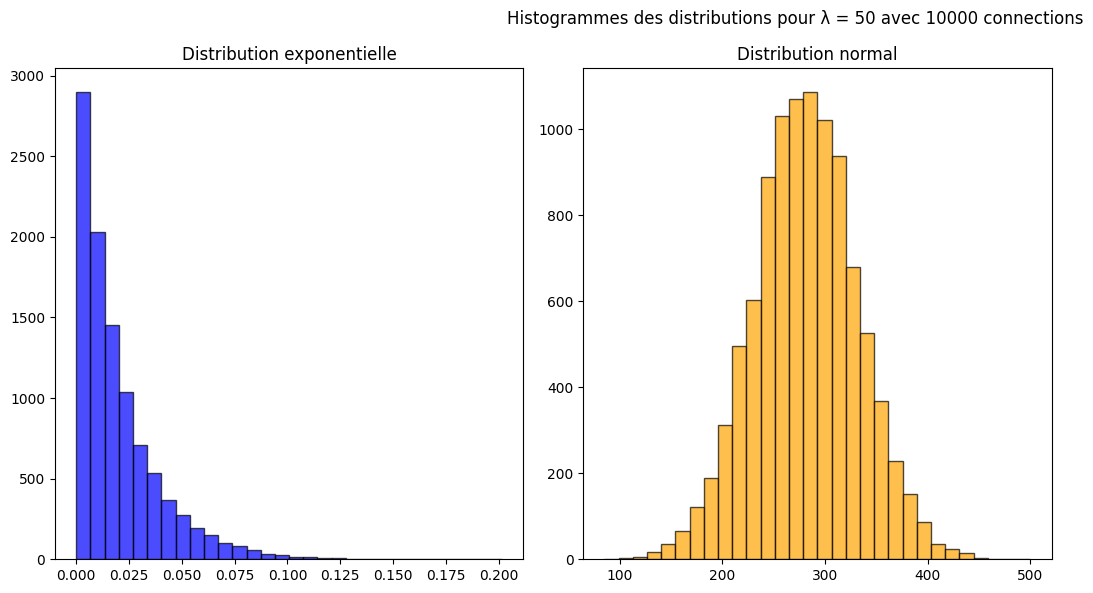

Nombre de joueurs présents pour 300 minutes : 3521


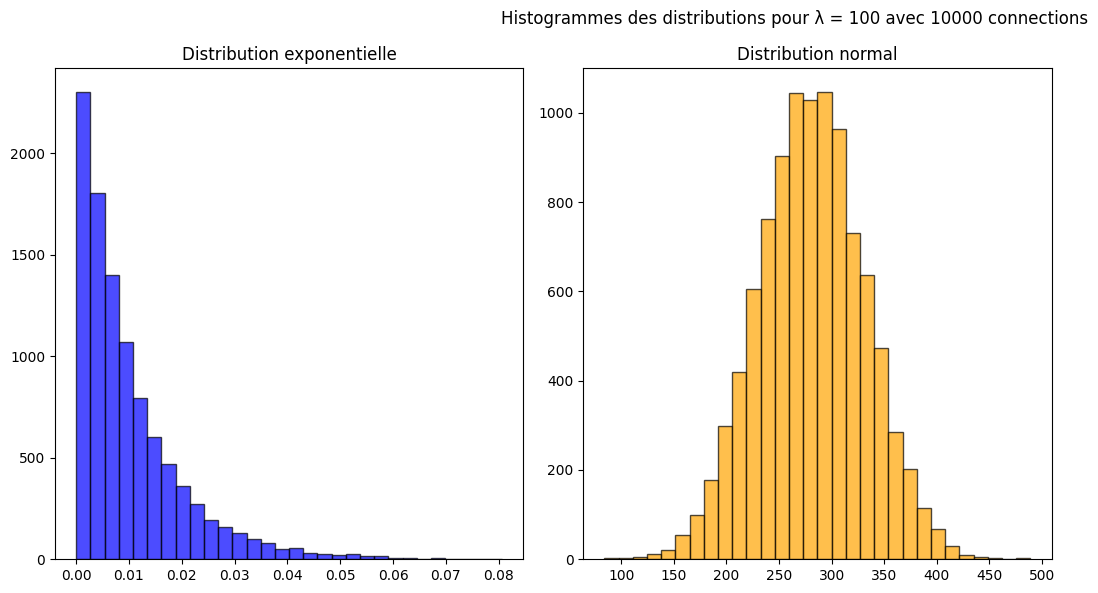

In [59]:
def sim(λ, t):
    N = 10_000
    
    P = np.random.exponential(1/λ, N) # intervalles
    P = P[P <= t] # instants de branchement

    u = 280.58
    o = 50.12
    Q = np.random.normal(u, o, N) # temps joué

    R = P + Q # temps joué fini
    J = np.sum((P <= t) & (R >=t)) # joueurs présents
    print(f'Nombre de joueurs présents pour {t} minutes : {J}')

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 3, 1)
    plt.hist(P, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Distribution exponentielle')
    plt.subplot(1, 3, 2)
    plt.hist(Q, bins=30, alpha=0.7, color='orange', edgecolor='black')
    plt.title(f'Distribution normal')
    plt.suptitle(f'Histogrammes des distributions pour λ = {λ} avec {N} connections')
    plt.tight_layout()
    plt.show()

λs = [10, 50, 100] # branchements
t = 300 # En minute

sim(λs[0], t)
sim(λs[1], t)
sim(λs[2], t)



λ =  10 | joueurs simulés =  10100 | joueurs présents = 2707


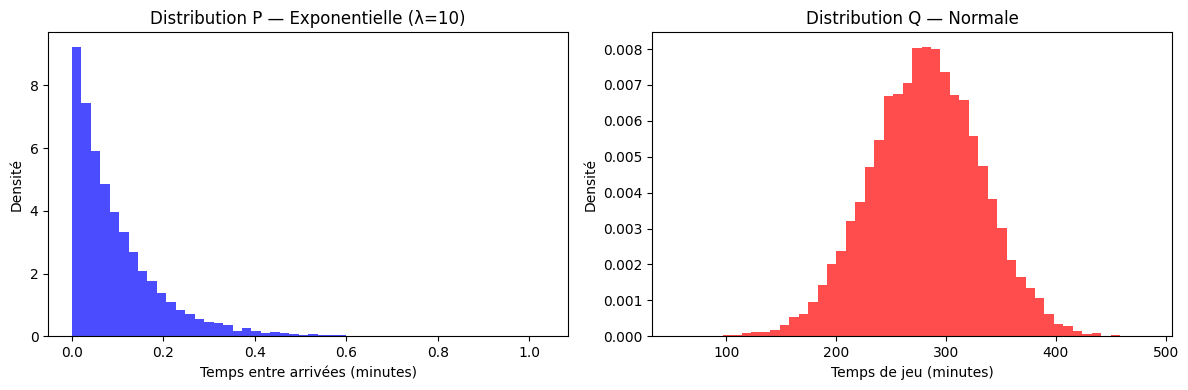

λ =  42 | joueurs simulés =  42420 | joueurs présents = 11669


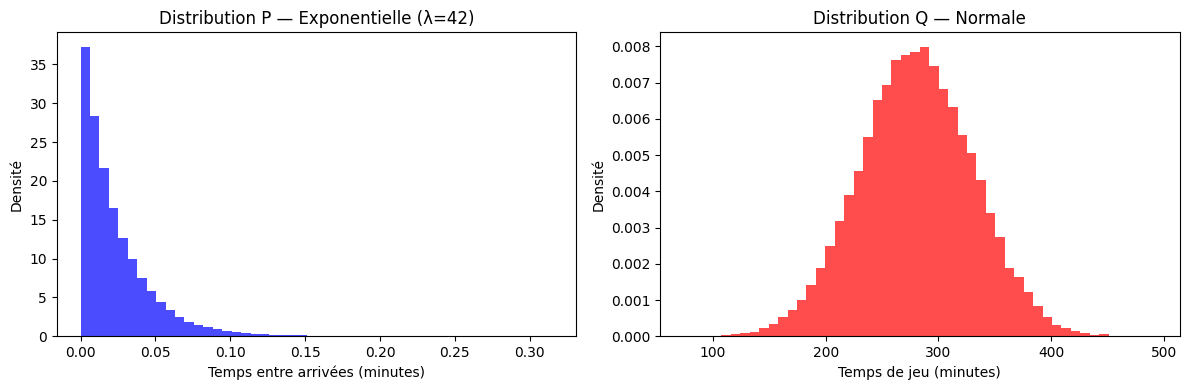

λ =  69 | joueurs simulés =  69690 | joueurs présents = 19212


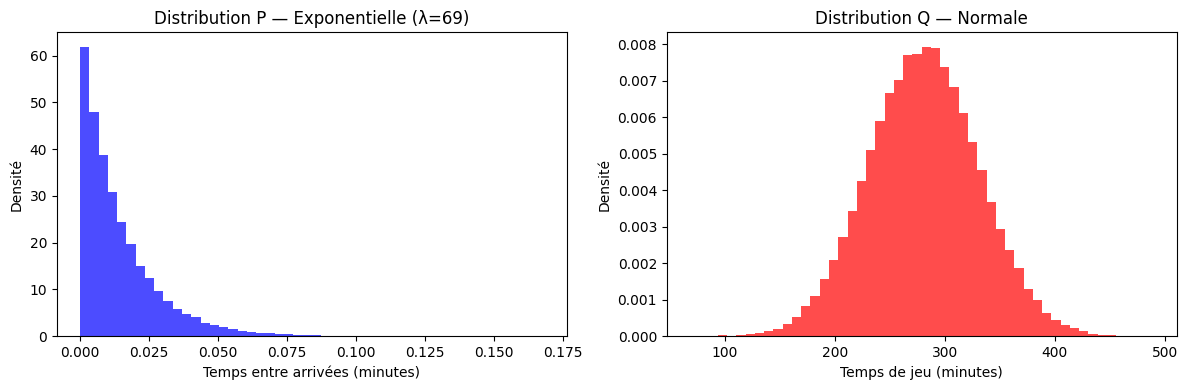

λ = 100 | joueurs simulés = 101000 | joueurs présents = 27693


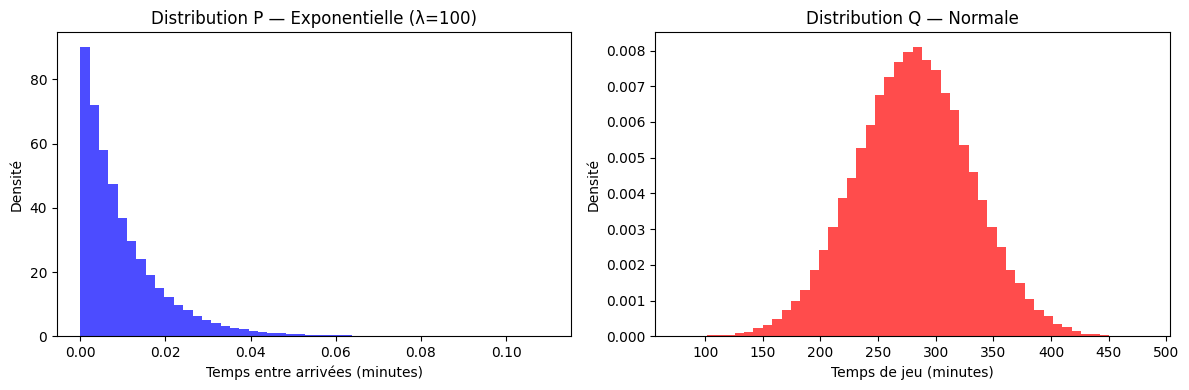

In [45]:
mu_Q    = 280.58
sigma_Q = 50.12

# échantillonnage par transformation inverse
def generer_P(lam, n):
    U = np.random.uniform(0, 1, n)
    return -1/lam * np.log(1 - U)

# Box_Muller
def generer_Q(mu, sigma, n):
    U1 = np.random.uniform(0, 1, n)
    U2 = np.random.uniform(0, 1, n)
    Z  = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    return mu + sigma * Z

temps_max = 1010
lambdas = [10, 42, 69, 100]
resultats = {}

for lam in lambdas:

    # pour avoir au moins 10000 joueurs
    nb_simulations = int(lam * temps_max)

    # Générer les intervalles entre les joueurs
    intervalles = generer_P(lam, nb_simulations)

    # Calculer les instants de branchement
    instants_branchement = np.cumsum(intervalles)

    # Garder seulement les branchements dans la fenêtre de temps
    instants_branchement = instants_branchement[instants_branchement <= temps_max]
    nb_joueurs = len(instants_branchement)

    # Générer le temps de jeu de chaque joueur
    temps_jeu = np.abs(generer_Q(mu_Q, sigma_Q, nb_joueurs))

    # Calculer instant de débranchement
    instants_fin = instants_branchement + temps_jeu

    # Compter joueurs présents à t = temps_max
    joueurs_presents = np.sum(
        (instants_branchement <= temps_max) &
        (instants_fin         >= temps_max)
    )

    resultats[lam] = joueurs_presents
    print(f"λ = {lam:3d} | joueurs simulés = {nb_joueurs:6d} | joueurs présents = {joueurs_presents}")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.hist(intervalles, bins=50, density=True, color='blue', alpha=0.7)
    ax1.set_title(f'Distribution P — Exponentielle (λ={lam})')
    ax1.set_xlabel('Temps entre arrivées (minutes)')
    ax1.set_ylabel('Densité')

    ax2.hist(temps_jeu, bins=50, density=True, color='red', alpha=0.7)
    ax2.set_title('Distribution Q — Normale')
    ax2.set_xlabel('Temps de jeu (minutes)')
    ax2.set_ylabel('Densité')

    plt.tight_layout()
    plt.show()